In [1]:
import numpy as np
import pandas as pd

# Generating data

y = (x * z)³

In [2]:
x_data = np.random.uniform(low=0, high=1.0, size=(1000,))  # TODO: Back to 3000
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=0, high=1.0, size=(1000,))
pow_data = np.power(x_data * z_data, 1)
multi_data = x_data * z_data

df_power = pd.DataFrame(np.array([x_data, z_data, pow_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_multi = pd.DataFrame(np.array([x_data, z_data, multi_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_power

,x_data,z_data,y_data
0,0.442027,0.046053,0.020357
1,0.178768,0.690568,0.123452
2,0.650852,0.455470,0.296443
3,0.451744,0.969959,0.438173
4,0.863646,0.437692,0.378011
...,...,...,...
995,0.242684,0.863131,0.209468
996,0.596986,0.257458,0.153699
997,0.776724,0.764300,0.593650
998,0.884629,0.451073,0.399032


In [3]:
df_multi

,x_data,z_data,y_data
0,0.442027,0.046053,0.020357
1,0.178768,0.690568,0.123452
2,0.650852,0.455470,0.296443
3,0.451744,0.969959,0.438173
4,0.863646,0.437692,0.378011
...,...,...,...
995,0.242684,0.863131,0.209468
996,0.596986,0.257458,0.153699
997,0.776724,0.764300,0.593650
998,0.884629,0.451073,0.399032


In [3]:
import spice_net as spn

#spn.approximate_local_min(-4, 4, eps=0.05, t=0.005, function=lambda x: (x - 3) ** 2)
spn.approximate_local_min_axenie(-7, 10, tolerance=abs((1.0e-6) * (-7 + 10) / 2.0), function=lambda x: (x - 3) ** 2 + 1)

3.0000004172325134

In [5]:


som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        key='product',
                        value_range_start=-1.0,
                        value_range_end=1.0,
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8),
                        dimensions=2)
som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        key='y_data',
                        value_range_start=df_power['y_data'].min(),
                        value_range_end=df_power['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm([som_1, som_2], spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [6]:
input_data = df_power[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
spice_net.fit({'product': input_data, 'y_data': df_power['y_data'].tolist()}, 10, 10, print_output=True)


100%|██████████| 100/100 [00:17<00:00,  5.83it/s]

Time spend on the Components: 
Som: 11.57243824005127 s | Convolution Matrix: 5.503193616867065 s


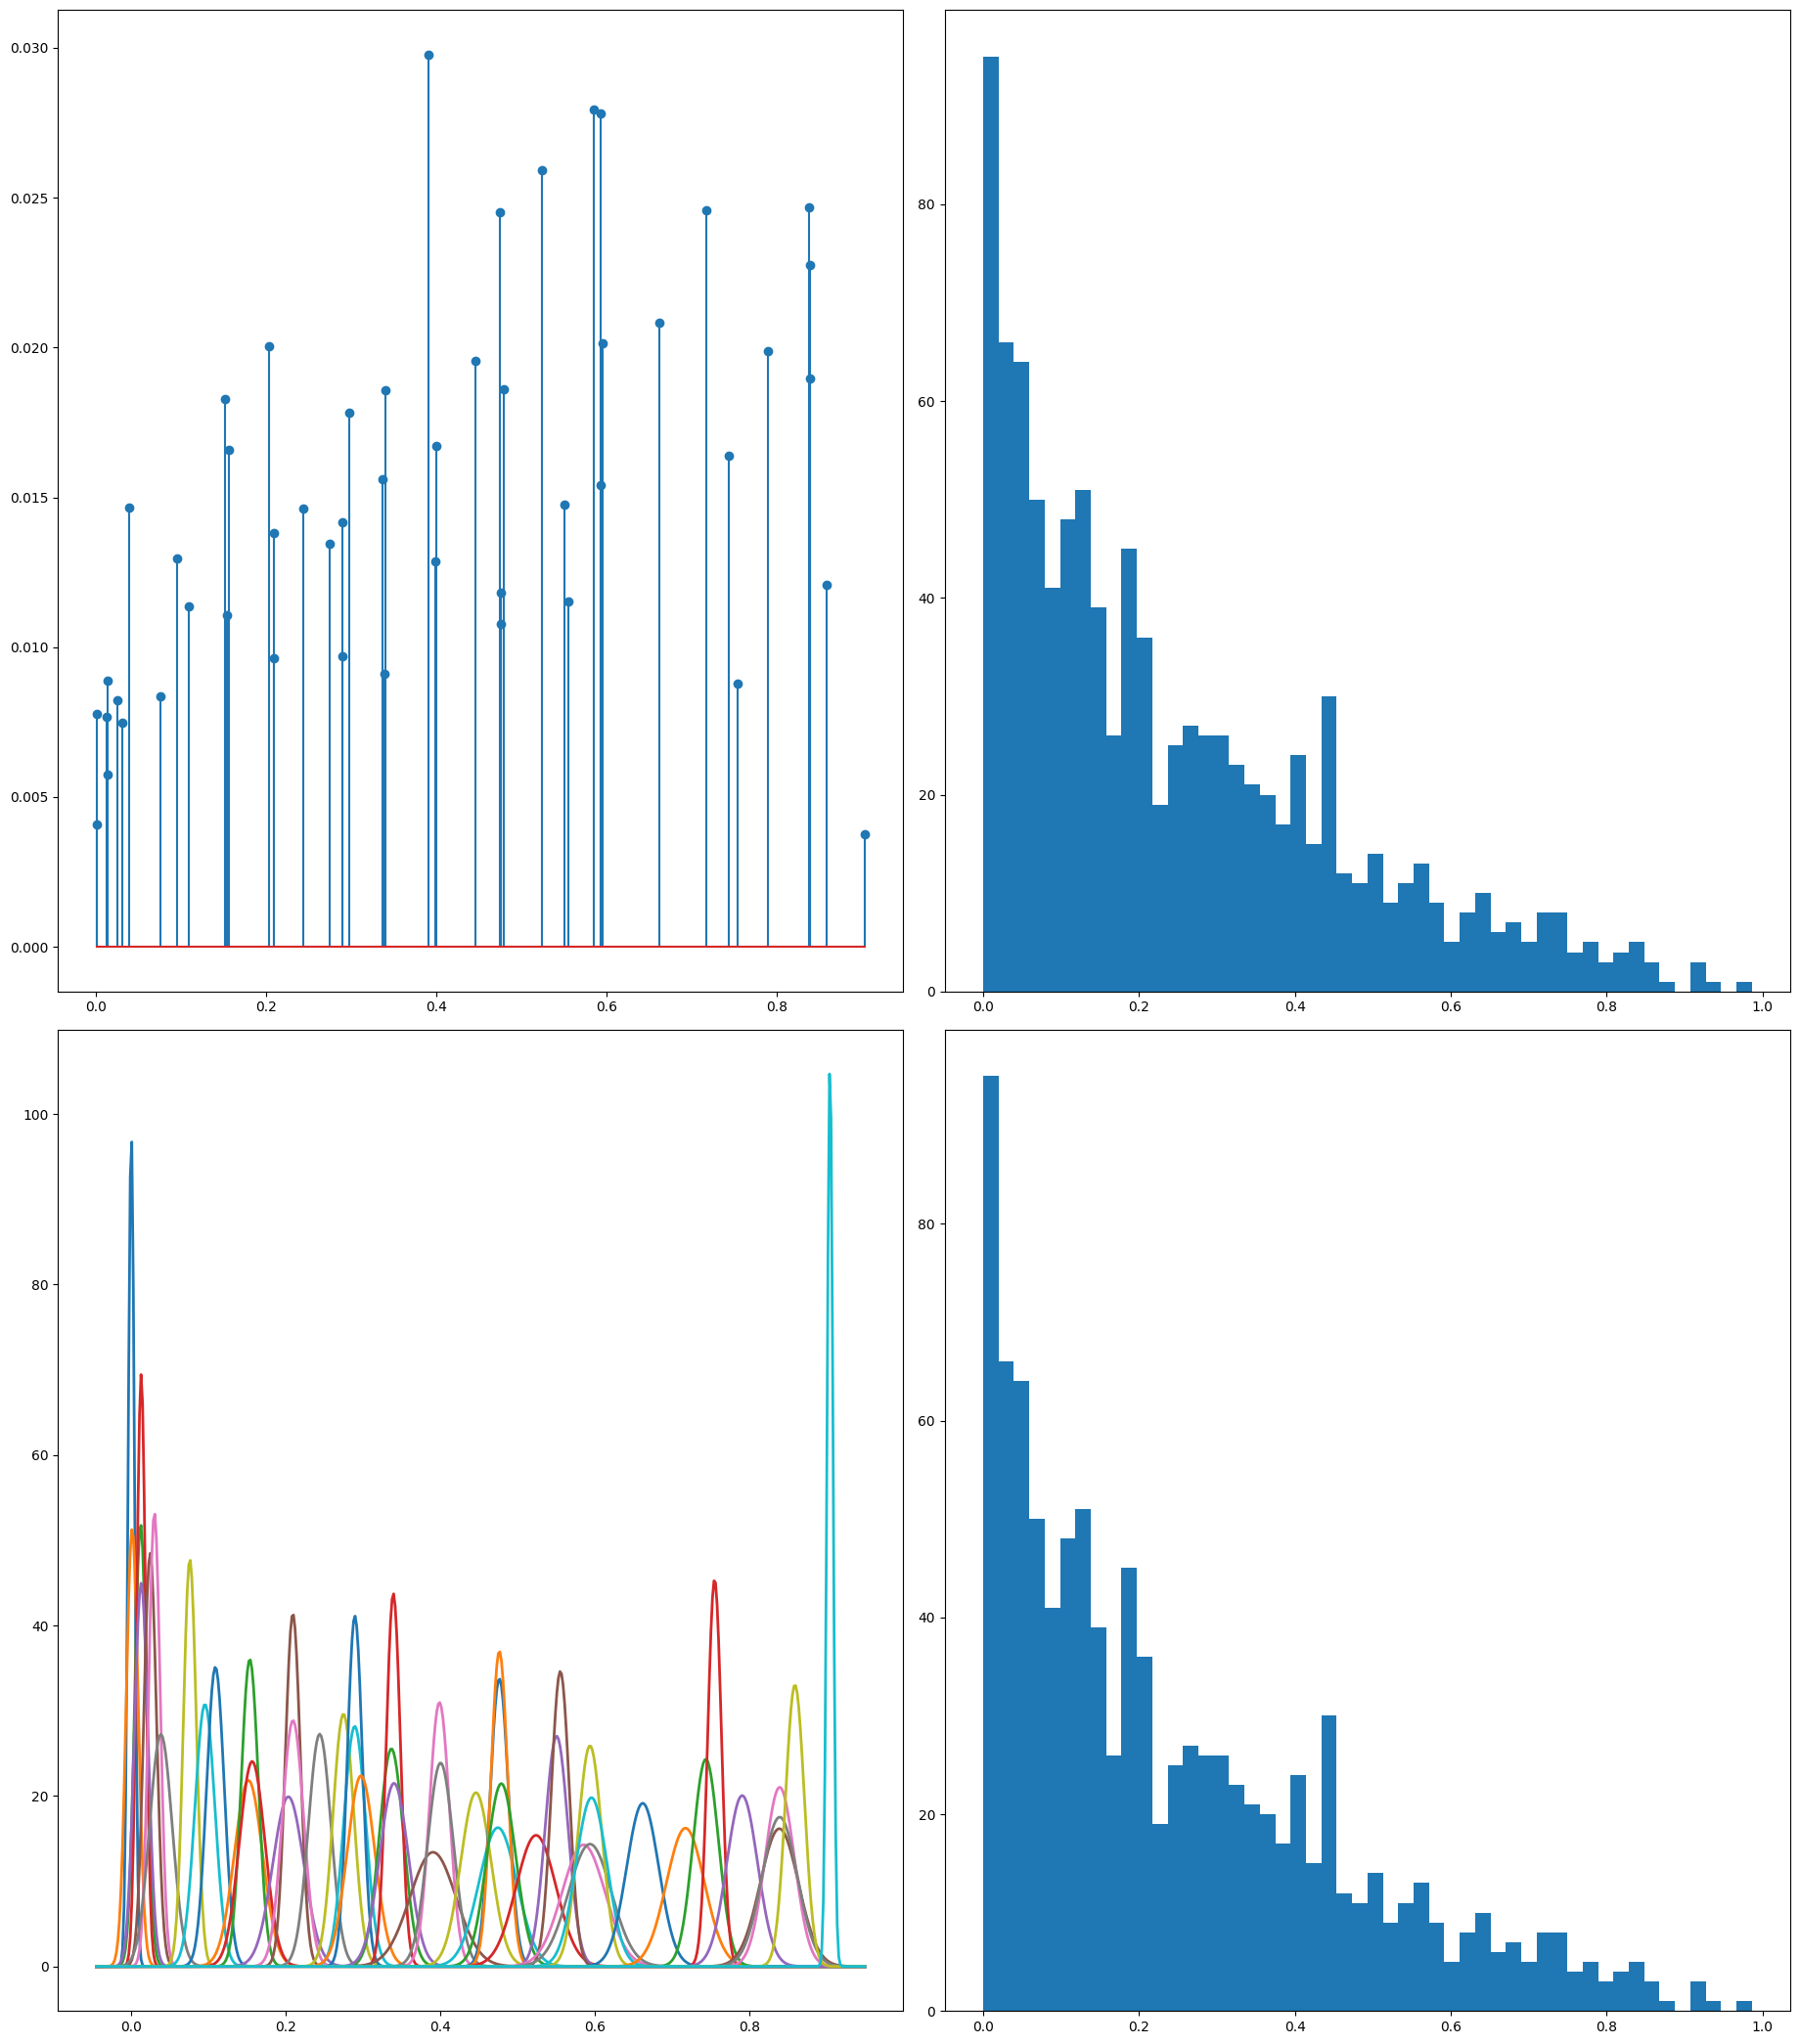

In [7]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, True)
spn.plot_som_comparison_to_data(som_2, df_power['y_data'].tolist())

In [8]:
errors = []

for i in range(100):
    test_data = df_power.sample()
    inti_test_value = test_data[['x_data', 'z_data']].iloc[0].to_numpy()
    result_test_value = test_data['y_data'].iloc[0]
    predicted = spice_net.decode({'product': inti_test_value}, decoder='bert-optimizer')
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')

Error: 9.335331,	 Predicted: 0.898724,	 Actual: 0.712018
Error: 1.676750,	 Predicted: 0.178635,	 Actual: 0.212170
Error: 0.061566,	 Predicted: 0.001604,	 Actual: 0.000373
Error: 8.945179,	 Predicted: 0.209540,	 Actual: 0.388444
Error: 1.465593,	 Predicted: 0.279178,	 Actual: 0.249867
Error: 6.162568,	 Predicted: 0.559247,	 Actual: 0.435995
Error: 15.611861,	 Predicted: 0.390632,	 Actual: 0.702870
Error: 0.056200,	 Predicted: 0.024849,	 Actual: 0.025973
Error: 1.632157,	 Predicted: 0.203562,	 Actual: 0.236206
Error: 23.381858,	 Predicted: 0.396583,	 Actual: 0.864220
Error: 6.327802,	 Predicted: 0.557672,	 Actual: 0.431116
Error: 5.079673,	 Predicted: 0.026721,	 Actual: 0.128314
Error: 0.572616,	 Predicted: 0.001604,	 Actual: 0.013057
Error: 3.178944,	 Predicted: 0.086545,	 Actual: 0.022967
Error: 0.305011,	 Predicted: 0.012490,	 Actual: 0.018590
Error: 14.234270,	 Predicted: 0.397241,	 Actual: 0.681926
Error: 0.546270,	 Predicted: 0.001604,	 Actual: 0.012530
Error: 2.888022,	 Predicted:

In [11]:
test_set = df_power.sample(1000)
test_set.sort_values(by=['y_data'])
errors = []
errors_distance = []
predicted_values = []

for _, row in test_set.iterrows():
    test_data = row
    result_test_value = test_data['y_data']
    inti_test_value = test_data[['x_data', 'z_data']].to_numpy()
    predicted = spice_net.decode({'product': inti_test_value},
                                 decoder='bert-optimizer')
    predicted_values.append(predicted)
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    errors_distance.append(abs(predicted - result_test_value))
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error distance {np.mean(np.array(errors_distance))}')
print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')
print(f'Error std {np.std(np.array(errors))}')

Error: 22.738497,	 Predicted: 0.013256,	 Actual: 0.468026
Error: 12.772188,	 Predicted: 0.765965,	 Actual: 0.510521
Error: 0.543010,	 Predicted: 0.013256,	 Actual: 0.002396
Error: 2.465303,	 Predicted: 0.012490,	 Actual: 0.061796
Error: 0.815272,	 Predicted: 0.001604,	 Actual: 0.017910
Error: 5.923891,	 Predicted: 0.092714,	 Actual: 0.211192
Error: 4.721973,	 Predicted: 0.296396,	 Actual: 0.201957
Error: 19.779338,	 Predicted: 0.397368,	 Actual: 0.792955
Error: 22.162617,	 Predicted: 0.390632,	 Actual: 0.833885
Error: 14.768648,	 Predicted: 0.766408,	 Actual: 0.471035
Error: 1.554012,	 Predicted: 0.012490,	 Actual: 0.043570
Error: 4.209914,	 Predicted: 0.280480,	 Actual: 0.196281
Error: 1.696114,	 Predicted: 0.024849,	 Actual: 0.058771
Error: 2.119708,	 Predicted: 0.012490,	 Actual: 0.054884
Error: 5.474667,	 Predicted: 0.007416,	 Actual: 0.116909
Error: 4.844215,	 Predicted: 0.036134,	 Actual: 0.133018
Error: 11.581071,	 Predicted: 0.766291,	 Actual: 0.534669
Error: 2.088700,	 Predict

In [12]:
import plotly.express as px

direction = test_set['y_data'].to_numpy() - np.array(predicted_values)
error_df = pd.DataFrame(
    {'Index': range(1, len(errors) + 1),
     'Real': test_set['y_data'],
     'Distance': errors_distance,
     'dir': direction.tolist()})
fig = px.scatter(error_df, x="Index", y="Real", error_y="Distance")
fig.add_scatter(x=error_df['Index'].to_numpy(), y=predicted_values, fillcolor='orange', mode='markers',
                name='Predicted', zorder=1000)
#fig.add_scatter(x=error_df['Index'].to_numpy(), y=error_df['Real'].to_numpy(), fillcolor='green')
fig.show()